# Loan Approval & Risk Prediction System

## Importing Libraries

In [22]:
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Loading Data from SQL

In [24]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="-------------",
    database="loan_prediction_db")

query = "SELECT * FROM loans"
df = pd.read_sql(query, conn)

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_5804\465078385.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history,property_area,loan_status,id,total_income,income_loan_ratio,emi
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0,1,6091.0,47.5859,0.355556
1,LP001955,Female,No,0,Graduate,No,5000.0,2541.0,151.0,480.0,1.0,Rural,0,2,7541.0,49.9404,0.314583
2,LP001357,Male,,,Graduate,No,3816.0,754.0,160.0,360.0,1.0,Urban,1,3,4570.0,28.5625,0.444444
3,LP002602,Male,No,0,Graduate,No,6283.0,4416.0,209.0,360.0,0.0,Rural,0,4,10699.0,51.1914,0.580556
4,LP002603,Female,No,0,Graduate,No,645.0,3683.0,113.0,480.0,1.0,Rural,1,5,4328.0,38.3009,0.235417


## Data Overview

In [25]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529 entries, 0 to 528
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             529 non-null    object 
 1   gender              529 non-null    object 
 2   married             529 non-null    object 
 3   dependents          529 non-null    object 
 4   education           529 non-null    object 
 5   self_employed       529 non-null    object 
 6   applicant_income    529 non-null    float64
 7   coapplicant_income  529 non-null    float64
 8   loan_amount         529 non-null    float64
 9   loan_term           529 non-null    float64
 10  credit_history      529 non-null    float64
 11  property_area       529 non-null    object 
 12  loan_status         529 non-null    object 
 13  id                  529 non-null    int64  
 14  total_income        529 non-null    float64
 15  income_loan_ratio   529 non-null    float64
 16  emi     

,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history,id,total_income,income_loan_ratio,emi
count,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000
mean,5507.822306,1542.394934,145.852552,342.351607,0.850662,265.000000,7050.217240,51.663996,0.462362
std,6404.132369,2524.295797,84.108409,64.861662,0.356759,152.853416,6589.393544,39.382389,0.378302
min,150.000000,0.000000,9.000000,36.000000,0.000000,1.000000,1442.000000,12.090200,0.025000
25%,2900.000000,0.000000,100.000000,360.000000,1.000000,133.000000,4166.000000,35.535700,0.286111
50%,3816.000000,1086.000000,128.000000,360.000000,1.000000,265.000000,5332.000000,41.443900,0.363889
75%,5815.000000,2232.000000,167.000000,360.000000,1.000000,397.000000,7542.000000,51.695700,0.506667
max,81000.000000,33837.000000,700.000000,480.000000,1.000000,529.000000,81000.000000,396.367000,4.305560


## Data Cleaning

In [26]:
# Fix dependents
df['dependents'] = df['dependents'].replace({'3+': 3, '': np.nan})      # empty - NaN
df['dependents'] = pd.to_numeric(df['dependents'], errors='coerce')
df['dependents'].fillna(df['dependents'].median(), inplace=True)

# Convert loan_status to numeric
df['loan_status'] = df['loan_status'].astype(int)

C:\Users\hp\AppData\Local\Temp\ipykernel_5804\338682834.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dependents'].fillna(df['dependents'].median(), inplace=True)


## Feature Engineering

In [27]:
df['total_income'] = df['applicant_income'] + df['coapplicant_income']
df['income_loan_ratio'] = df['total_income'] / df['loan_amount']
df['emi'] = df['loan_amount'] / df['loan_term']

## EDA

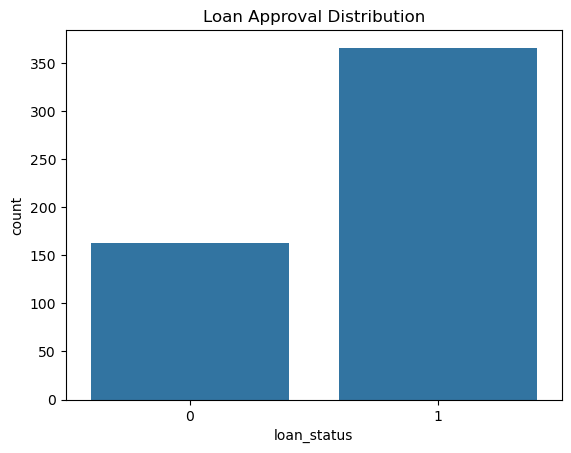

In [28]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

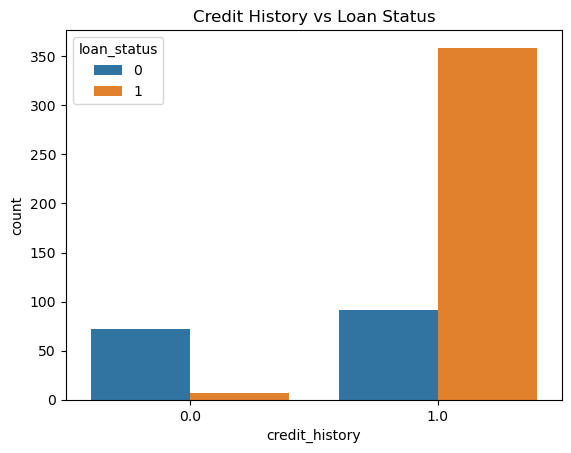

In [29]:
sns.countplot(x='credit_history', hue='loan_status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

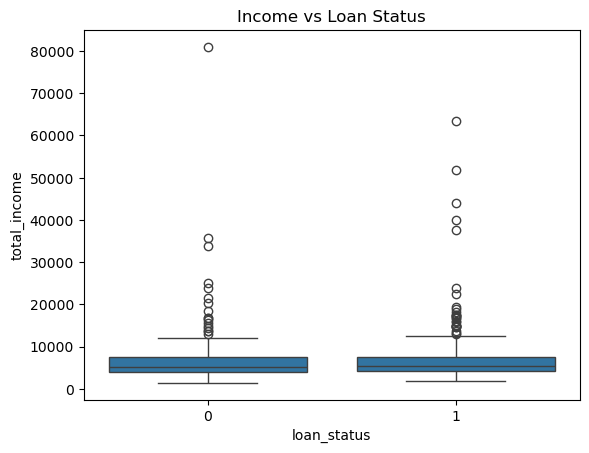

In [30]:
sns.boxplot(x='loan_status', y='total_income', data=df)
plt.title("Income vs Loan Status")
plt.show()

## Encoding

In [31]:
le = LabelEncoder()

categorical_cols = ['gender', 'married', 'education','self_employed', 'property_area']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Preparing Data

In [32]:
# Drop unnecessary column                               
df = df.drop('loan_id', axis=1)

# Features & Target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

## Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MODEL BUILDING

In [34]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
### Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [36]:
### Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

## Evaluation Function

In [37]:
def evaluate_model(y_test, y_pred, y_prob, model_name): 
    print(f"--- {model_name} ---")
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

In [38]:
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, y_prob_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")

--- Logistic Regression ---
Accuracy: 0.7735849056603774
ROC-AUC: 0.7198622273249139

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.44      0.59        39
           1       0.75      0.97      0.84        67

    accuracy                           0.77       106
   macro avg       0.82      0.70      0.72       106
weighted avg       0.80      0.77      0.75       106


Confusion Matrix:
 [[17 22]
 [ 2 65]]


--- Decision Tree ---
Accuracy: 0.7358490566037735
ROC-AUC: 0.7267508610792193

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.69      0.66        39
           1       0.81      0.76      0.78        67

    accuracy                           0.74       106
   macro avg       0.72      0.73      0.72       106
weighted avg       0.74      0.74      0.74       106


Confusion Matrix:
 [[27 12]
 [16 51]]


--- Random Forest ---
Accuracy: 0.8018867924528302

## ROC Curve

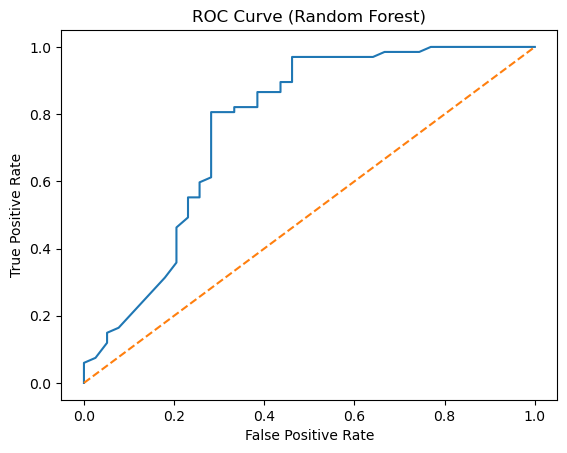

In [32]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve (Random Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## Risk Segmentation

In [39]:
df['risk_prob'] = rf.predict_proba(X)[:, 1]

In [43]:
df_test = X_test.copy()
df_test['risk_prob'] = y_prob_rf

def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

df_test['risk_level'] = df_test['risk_prob'].apply(risk_category)

df_test[['risk_prob', 'risk_level']].head()

,risk_prob,risk_level
140,0.66,Medium Risk
397,0.31,Medium Risk
6,0.62,Medium Risk
334,0.12,Low Risk
322,0.87,High Risk


In [46]:
df.to_csv("final_loan_data.csv", index=False)

# Conclusion

- Random Forest emerged as the best-performing model with the highest accuracy (~80%) and ROC-AUC (~0.76), indicating a stronger ability to distinguish between approved and rejected loan applicants compared to Logistic Regression and Decision Tree.

- Logistic Regression showed high recall (0.97) for approved loans but struggled to correctly identify rejected applicants, leading to a higher number of false approvals.

- Across all models, recall for approved loans (class 1) is very high, but recall for rejected loans (class 0) is relatively low — indicating the model is biased toward approval and may allow risky applicants.

- Credit-related factors (especially Credit History) and income-based features played a significant role in determining loan approval outcomes.

- The confusion matrix shows that a key challenge is reducing false positives (approving risky applicants), which is critical for minimizing financial risk in real-world banking systems.

- The introduction of risk segmentation (Low / Medium / High) provides a more practical decision-making framework, allowing banks to go beyond binary approval and apply risk-based strategies.

- Overall, the model can support automated loan decision systems, but further tuning is required to better balance risk (reducing false approvals) and business opportunity (not rejecting good customers).